## Testing set up for capturing video frames

In [2]:
import subprocess
result = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
print(result.stdout.split("\n")[0])   # should print ffmpeg version

ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers


In [1]:
# Cell — Download a short YouTube clip as your test video
import yt_dlp
from pathlib import Path

Path("tests/sample_videos").mkdir(parents=True, exist_ok=True)

# A 30-second public domain clip — short and fast to download
url = "https://www.youtube.com/watch?v=aqz-KE-bpKQ"  # Big Buck Bunny trailer, ~30s

ydl_opts = {
    "format": "mp4[height<=480]/best[ext=mp4]",   # small resolution, fast download
    "outtmpl": "tests/sample_videos/sample.mp4",
    "quiet": False,
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

[youtube] Extracting URL: https://www.youtube.com/watch?v=aqz-KE-bpKQ
[youtube] aqz-KE-bpKQ: Downloading webpage


[youtube] aqz-KE-bpKQ: Downloading android vr player API JSON
[info] aqz-KE-bpKQ: Downloading 1 format(s): 18
[download] Destination: tests/sample_videos/sample.mp4
[download] 100% of   27.20MiB in 00:00:02 at 11.47MiB/s    


FPS      : 30.00
Duration : 634.58s


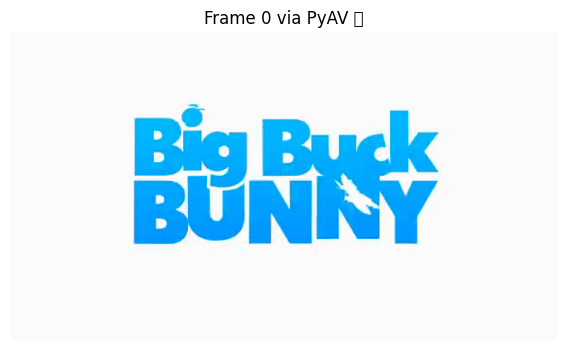

In [7]:
# Cell — Verify PyAV can read the video (replaces decord cell)
import av
import matplotlib.pyplot as plt

with av.open("tests/sample_videos/sample.mp4") as container:
    stream = container.streams.video[0]
    duration = float(container.duration) / 1_000_000
    fps = float(stream.average_rate)
    print(f"FPS      : {fps:.2f}")
    print(f"Duration : {duration:.2f}s")

    # Grab first frame
    for i, frame in enumerate(container.decode(video=0)):
        if i == 30:   # ← this is the frame number
            img = frame.to_ndarray(format="rgb24")
            break

plt.figure(figsize=(8, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Frame 0 via PyAV ✅")
plt.show()